# Product Analytics Case Study – User Activation & Retention

## Objective

Analyze real-world user behavior data to understand how users engage with a digital product, identify key drop-off points in the user journey, and determine which early behaviors are associated with continued product usage.

The analysis uses Python and SQL to define activation and retention metrics, identify behavioral patterns, and translate the findings into a product improvement proposal.

An A/B testing framework is then designed to evaluate the proposed product change and measure its potential impact on activation and retention.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Exploration

The dataset contains event-level user activity from an e-commerce platform. Before performing the product analysis, the raw data is inspected to understand its structure, data types, completeness, and overall quality.

In [2]:
df = pd.read_csv("../data/2019-Oct.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4102283, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


### Data Quality Assessment

Before cleaning the dataset, its schema, missing values, duplicate records, and event distribution are examined to identify potential data quality issues.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4102283 entries, 0 to 4102282
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 281.7 MB


In [4]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)

pd.DataFrame({
    "missing_values": missing_values,
    "missing_percentage": missing_percentage
})

,missing_values,missing_percentage
event_time,0,0.00
event_type,0,0.00
product_id,0,0.00
category_id,0,0.00
category_code,4034806,98.36
brand,1659261,40.45
price,0,0.00
user_id,0,0.00
user_session,637,0.02


In [5]:
print("Duplicate rows:", df.duplicated().sum())

print("\nEvent types:")
print(df["event_type"].value_counts())

Duplicate rows: 213155

Event types:
event_type
view                1862164
cart                1232385
remove_from_cart     762110
purchase             245624
Name: count, dtype: int64


In [6]:
print("Unique users:", df["user_id"].nunique())
print("Unique sessions:", df["user_session"].nunique())
print("Unique products:", df["product_id"].nunique())

print("\nPrice summary:")
print(df["price"].describe())

Unique users: 399664
Unique sessions: 873960
Unique products: 41899

Price summary:
count    4.102283e+06
mean     8.534920e+00
std      1.913315e+01
min     -7.937000e+01
25%      2.140000e+00
50%      4.110000e+00
75%      7.140000e+00
max      3.076000e+02
Name: price, dtype: float64


In [7]:
print("Negative prices:", (df["price"] < 0).sum())
print("Zero prices:", (df["price"] == 0).sum())

df[df["price"] <= 0][
    ["event_time", "event_type", "product_id", "price", "user_id"]
].head(20)

Negative prices: 20
Zero prices: 6066


,event_time,event_type,product_id,price,user_id
2454,2019-10-01 02:05:17 UTC,view,5892084,0.0,555458569
2614,2019-10-01 02:15:41 UTC,view,5892052,0.0,555455025
5686,2019-10-01 04:25:00 UTC,view,5873432,0.0,500054739
6086,2019-10-01 04:33:15 UTC,view,5882605,0.0,523154930
8344,2019-10-01 05:16:30 UTC,view,5889621,0.0,523988665
8417,2019-10-01 05:18:03 UTC,view,5889622,0.0,523988665
8465,2019-10-01 05:18:46 UTC,view,5889623,0.0,523988665
8950,2019-10-01 05:24:38 UTC,view,5873431,0.0,542778344
10125,2019-10-01 05:38:01 UTC,view,5889627,0.0,523988665
10154,2019-10-01 05:38:32 UTC,view,5889628,0.0,523988665


In [8]:
df[df["price"] < 0]["event_type"].value_counts()

event_type
purchase    20
Name: count, dtype: int64

## 2. Data Cleaning

The initial data quality assessment identified duplicate events, substantial missingness in `category_code`, a small number of missing session identifiers, and several unusual price values.

The following cleaning decisions were made:

- Exact duplicate rows are removed to avoid double-counting user events.
- `event_time` is converted from text to a datetime format to enable time-based behavioral and retention analysis.
- `category_code` is removed because more than 98% of its values are missing.
- Missing `brand` values are retained because brand information is not required for the core activation and retention analysis.
- Events with missing `user_session` are retained for user-level analysis, but excluded where session-level metrics require a valid session identifier.
- Zero and negative prices are retained because price is not used in the core activation, retention, or funnel metrics analyzed in this case study.

In [9]:
df_clean = df.copy()

# Remove exact duplicate events
df_clean = df_clean.drop_duplicates()

# Convert event time to datetime
df_clean["event_time"] = pd.to_datetime(df_clean["event_time"])

# Remove category_code due to excessive missingness
df_clean = df_clean.drop(columns=["category_code"])

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

df_clean.info()

Original rows: 4102283
Clean rows: 3889128
Rows removed: 213155
<class 'pandas.DataFrame'>
Index: 3889128 entries, 0 to 4102282
Data columns (total 8 columns):
 #   Column        Dtype              
---  ------        -----              
 0   event_time    datetime64[us, UTC]
 1   event_type    str                
 2   product_id    int64              
 3   category_id   int64              
 4   brand         str                
 5   price         float64            
 6   user_id       int64              
 7   user_session  str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(3)
memory usage: 267.0 MB


## 3. Defining the Analysis Window

Before defining activation and retention metrics, the time coverage of the dataset is examined to ensure that users have sufficient observation time.

Because the dataset contains behavioral events rather than explicit signup dates, a user's first observed activity will be used as the beginning of their observed journey. This does not necessarily represent the user's actual signup date and will be treated as a limitation of the analysis.

In [10]:
print("Start date:", df_clean["event_time"].min())
print("End date:", df_clean["event_time"].max())
print("Number of days:", df_clean["event_time"].dt.date.nunique())

Start date: 2019-10-01 00:00:00+00:00
End date: 2019-10-31 23:59:54+00:00
Number of days: 31


In [11]:
events_per_day = (
    df_clean
    .assign(event_date=df_clean["event_time"].dt.date)
    .groupby("event_date")
    .size()
)

events_per_day

event_date
2019-10-01    134927
2019-10-02    190569
2019-10-03    118650
2019-10-04    109957
2019-10-05    100748
2019-10-06    175575
2019-10-07    171089
2019-10-08    139601
2019-10-09    132266
2019-10-10    125497
2019-10-11    112937
2019-10-12    105371
2019-10-13    110705
2019-10-14    127570
2019-10-15    124178
2019-10-16    129512
2019-10-17    127365
2019-10-18    113103
2019-10-19     98332
2019-10-20    108215
2019-10-21    132750
2019-10-22    129477
2019-10-23    126475
2019-10-24    123151
2019-10-25    106434
2019-10-26    103225
2019-10-27    120539
2019-10-28    125821
2019-10-29    128302
2019-10-30    119777
2019-10-31    117010
dtype: int64

## 4. Activation and Retention Framework

Because the dataset does not contain explicit signup dates, each user's first observed event is used as the starting point of their observed journey.

### Early engagement
User behavior during the first three days following the first observed activity is analyzed using metrics such as sessions, active days, product views, cart activity, and purchases.

Rather than defining activation arbitrarily, the analysis will identify which early behaviors are most strongly associated with subsequent user return. These findings will be used to define a meaningful activation signal.

### Retention
A user is considered retained if they generate at least one event during days 7–14 following their first observed activity.

Only users with a complete observation window are included in the retention analysis to avoid right-censoring.

In [12]:
first_activity = (
    df_clean.groupby("user_id")["event_time"]
    .min()
    .rename("first_activity")
)

df_clean = df_clean.join(first_activity, on="user_id")

df_clean["days_since_first_activity"] = (
    df_clean["event_time"].dt.normalize()
    - df_clean["first_activity"].dt.normalize()
).dt.days

df_clean[
    ["user_id", "event_time", "first_activity", "days_since_first_activity"]
].head(10)

,user_id,event_time,first_activity,days_since_first_activity
0,463240011,2019-10-01 00:00:00+00:00,2019-10-01 00:00:00+00:00,0
1,463240011,2019-10-01 00:00:03+00:00,2019-10-01 00:00:00+00:00,0
2,429681830,2019-10-01 00:00:07+00:00,2019-10-01 00:00:07+00:00,0
3,463240011,2019-10-01 00:00:07+00:00,2019-10-01 00:00:00+00:00,0
4,429681830,2019-10-01 00:00:15+00:00,2019-10-01 00:00:07+00:00,0
5,430174032,2019-10-01 00:00:16+00:00,2019-10-01 00:00:16+00:00,0
6,377667011,2019-10-01 00:00:19+00:00,2019-10-01 00:00:19+00:00,0
7,467916806,2019-10-01 00:00:24+00:00,2019-10-01 00:00:24+00:00,0
8,385985999,2019-10-01 00:00:25+00:00,2019-10-01 00:00:25+00:00,0
9,474232307,2019-10-01 00:00:26+00:00,2019-10-01 00:00:26+00:00,0


In [13]:
df_clean["days_since_first_activity"].describe()

count    3.889128e+06
mean     4.589555e+00
std      7.285978e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.000000e+00
max      3.000000e+01
Name: days_since_first_activity, dtype: float64

## 5. Building the User-Level Behavioral Dataset

To compare retained and non-retained users, event-level data is transformed into a user-level dataset.

For each user, early behavior during days 0–2 is summarized using:
- number of events,
- number of sessions,
- number of active days,
- product views,
- cart events,
- purchases.

Retention is then measured independently based on whether the user returns during days 7–14 after their first observed activity.

In [14]:
early_events = df_clean[
    df_clean["days_since_first_activity"].between(0, 2)
].copy()

early_events.shape

(2481220, 10)

In [15]:
# Basic early engagement metrics per user
early_user_metrics = (
    early_events.groupby("user_id")
    .agg(
        early_events=("event_type", "size"),
        early_sessions=("user_session", "nunique"),
        early_active_days=("event_time", lambda x: x.dt.normalize().nunique())
    )
)

# Count each event type per user
event_counts = (
    early_events
    .groupby(["user_id", "event_type"])
    .size()
    .unstack(fill_value=0)
)

# Number of unique products viewed per user
products_viewed = (
    early_events[early_events["event_type"] == "view"]
    .groupby("user_id")["product_id"]
    .nunique()
    .rename("products_viewed")
)

# Combine all early behavior metrics
early_user_metrics = (
    early_user_metrics
    .join(event_counts)
    .join(products_viewed)
    .fillna(0)
    .reset_index()
)

# Rename event columns for clarity
early_user_metrics = early_user_metrics.rename(columns={
    "view": "view_events",
    "cart": "cart_events",
    "remove_from_cart": "remove_from_cart_events",
    "purchase": "purchase_events"
})

early_user_metrics.head()

,user_id,early_events,early_sessions,early_active_days,cart_events,purchase_events,remove_from_cart_events,view_events,products_viewed
0,4103071,8,1,1,1,0,0,7,6.0
1,8846226,43,2,2,24,0,12,7,6.0
2,9794320,19,1,1,13,0,4,2,2.0
3,10280338,12,1,1,6,0,0,6,6.0
4,10702733,2,1,1,0,0,0,2,2.0


## 6. Retention Cohort

Retention is measured as a return to the platform during days 7–14 after a user's first observed activity.

To ensure that every user has an equal opportunity to be observed throughout the full retention window, only users whose first observed activity occurs at least 14 days before the end of the dataset are included.

This avoids incorrectly classifying recently observed users as non-retained simply because insufficient follow-up data is available.

Because the dataset does not contain signup dates or user history before October 2019, this metric represents observed return behavior rather than true signup-based retention.

In [16]:
observation_end = df_clean["event_time"].max().normalize()

eligible_user_ids = first_activity[
    first_activity.dt.normalize()
    <= observation_end - pd.Timedelta(days=14)
].index

total_users = df_clean["user_id"].nunique()

print("Observation end:", observation_end)
print("Total users:", total_users)
print("Eligible users:", len(eligible_user_ids))
print(
    "Excluded due to incomplete observation window:",
    total_users - len(eligible_user_ids)
)

Observation end: 2019-10-31 00:00:00+00:00
Total users: 399664
Eligible users: 255728
Excluded due to incomplete observation window: 143936


## 7. Retention Outcome

For each eligible user, retention is defined as at least one observed event during days 7–14 following their first observed activity.

The resulting binary variable (`retained_7_14d`) serves as the outcome used to compare early behavioral patterns between retained and non-retained users.

In [17]:
retained_users = (
    df_clean[
        df_clean["days_since_first_activity"].between(7, 14)
    ]["user_id"]
    .unique()
)

user_analysis = early_user_metrics[
    early_user_metrics["user_id"].isin(eligible_user_ids)
].copy()

user_analysis["retained_7_14d"] = (
    user_analysis["user_id"]
    .isin(retained_users)
    .astype(int)
)

print("Users in analysis:", len(user_analysis))
print("Retained users:", user_analysis["retained_7_14d"].sum())
print(
    "Non-retained users:",
    (user_analysis["retained_7_14d"] == 0).sum()
)

retention_rate = user_analysis["retained_7_14d"].mean() * 100

print(f"7–14 day observed return rate: {retention_rate:.2f}%")

Users in analysis: 255728
Retained users: 23091
Non-retained users: 232637
7–14 day observed return rate: 9.03%


## 8. Early Behavior and Retention

To identify potential activation signals, early behavioral metrics are compared between users who returned during days 7–14 and those who did not.

The goal is to determine which behaviors during the first three observed days are associated with a higher likelihood of subsequent return.

In [18]:
behavior_metrics = [
    "early_events",
    "early_sessions",
    "early_active_days",
    "products_viewed",
    "view_events",
    "cart_events",
    "remove_from_cart_events",
    "purchase_events"
]

retention_comparison = (
    user_analysis
    .groupby("retained_7_14d")[behavior_metrics]
    .mean()
    .round(2)
    .T
)

retention_comparison.columns = ["Non-retained", "Retained"]

retention_comparison["Difference"] = (
    retention_comparison["Retained"]
    - retention_comparison["Non-retained"]
).round(2)

retention_comparison["Relative difference (%)"] = (
    (
        retention_comparison["Retained"]
        / retention_comparison["Non-retained"]
        - 1
    ) * 100
).round(1)

retention_comparison

,Non-retained,Retained,Difference,Relative difference (%)
early_events,5.35,18.20,12.85,240.2
early_sessions,1.48,2.83,1.35,91.2
early_active_days,1.08,1.38,0.30,27.8
products_viewed,2.12,6.14,4.02,189.6
view_events,2.59,8.09,5.50,212.4
cart_events,1.90,5.67,3.77,198.4
remove_from_cart_events,0.56,3.32,2.76,492.9
purchase_events,0.30,1.12,0.82,273.3


## 9. Exploring Potential Activation Signals

The initial comparison shows that retained users demonstrate substantially higher engagement during their first three observed days.

To identify a practical activation signal, retention is analyzed across different levels of early engagement. Early session frequency is examined first because it represents repeated interaction with the product and can potentially be influenced through product and onboarding decisions.

In [19]:
user_analysis["session_group"] = pd.cut(
    user_analysis["early_sessions"],
    bins=[0, 1, 2, 3, float("inf")],
    labels=["1 session", "2 sessions", "3 sessions", "4+ sessions"]
)

session_retention = (
    user_analysis
    .groupby("session_group", observed=True)
    .agg(
        users=("user_id", "count"),
        retained_users=("retained_7_14d", "sum"),
        retention_rate=("retained_7_14d", "mean")
    )
)

session_retention["retention_rate"] = (
    session_retention["retention_rate"] * 100
).round(2)

session_retention

,users,retained_users,retention_rate
session_group,,,
1 session,203206,12491,6.15
2 sessions,30573,4853,15.87
3 sessions,9352,2141,22.89
4+ sessions,12581,3605,28.65


In [20]:
active_days_retention = (
    user_analysis
    .groupby("early_active_days")
    .agg(
        users=("user_id", "count"),
        retained_users=("retained_7_14d", "sum"),
        retention_rate=("retained_7_14d", "mean")
    )
)

active_days_retention["retention_rate"] = (
    active_days_retention["retention_rate"] * 100
).round(2)

active_days_retention

,users,retained_users,retention_rate
early_active_days,,,
1,232610,15959,6.86
2,19566,5427,27.74
3,3552,1705,48.00


In [21]:
user_analysis["products_viewed_group"] = pd.cut(
    user_analysis["products_viewed"],
    bins=[-1, 1, 3, 5, 10, float("inf")],
    labels=["0–1", "2–3", "4–5", "6–10", "11+"]
)

product_depth_retention = (
    user_analysis
    .groupby("products_viewed_group", observed=True)
    .agg(
        users=("user_id", "count"),
        retained_users=("retained_7_14d", "sum"),
        retention_rate=("retained_7_14d", "mean")
    )
)

product_depth_retention["retention_rate"] = (
    product_depth_retention["retention_rate"] * 100
).round(2)

product_depth_retention

,users,retained_users,retention_rate
products_viewed_group,,,
0–1,183655,9126,4.97
2–3,39406,5315,13.49
4–5,11788,2428,20.60
6–10,10921,2745,25.14
11+,9958,3477,34.92


In [22]:
user_analysis["activation_candidate"] = (
    (user_analysis["early_sessions"] >= 2) &
    (user_analysis["products_viewed"] >= 4)
)

activation_comparison = (
    user_analysis
    .groupby("activation_candidate")
    .agg(
        users=("user_id", "count"),
        retained_users=("retained_7_14d", "sum"),
        retention_rate=("retained_7_14d", "mean")
    )
)

activation_comparison["retention_rate"] = (
    activation_comparison["retention_rate"] * 100
).round(2)

activation_comparison.index = [
    "Not activated",
    "Activated"
]

activation_comparison

,users,retained_users,retention_rate
Not activated,234630,16746,7.14
Activated,21098,6345,30.07


In [23]:
activation_rate = (
    user_analysis["activation_candidate"].mean() * 100
)

retention_lift = (
    activation_comparison.loc["Activated", "retention_rate"]
    / activation_comparison.loc["Not activated", "retention_rate"]
)

print(f"Activation rate: {activation_rate:.2f}%")
print(f"Retention ratio: {retention_lift:.2f}x")

Activation rate: 8.25%
Retention ratio: 4.21x


## 10. Activation Threshold Validation

Several activation thresholds are compared to evaluate the trade-off between the share of users reaching the milestone and the strength of its association with subsequent retention.

The goal is to select a practical activation definition that identifies meaningful early engagement without restricting activation to only a very small group of highly engaged users.

In [24]:
threshold_results = []

for min_products in [2, 4, 6, 8]:
    
    activated = (
        (user_analysis["early_sessions"] >= 2) &
        (user_analysis["products_viewed"] >= min_products)
    )
    
    activation_rate = activated.mean() * 100
    
    activated_retention = (
        user_analysis.loc[activated, "retained_7_14d"].mean() * 100
    )
    
    non_activated_retention = (
        user_analysis.loc[~activated, "retained_7_14d"].mean() * 100
    )
    
    retention_ratio = (
        activated_retention / non_activated_retention
    )
    
    threshold_results.append({
        "Activation definition": f"2+ sessions & {min_products}+ products",
        "Activation rate (%)": activation_rate,
        "Activated retention (%)": activated_retention,
        "Non-activated retention (%)": non_activated_retention,
        "Retention ratio": retention_ratio
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison.round(2)

,Activation definition,Activation rate (%),Activated retention (%),Non-activated retention (%),Retention ratio
0,2+ sessions & 2+ products,15.62,23.15,6.42,3.61
1,2+ sessions & 4+ products,8.25,30.07,7.14,4.21
2,2+ sessions & 6+ products,5.64,33.44,7.57,4.42
3,2+ sessions & 8+ products,4.20,35.43,7.87,4.50


### Selected Activation Metric

Based on the threshold analysis, the proposed activation milestone is:

**At least 2 sessions and at least 4 unique products viewed within the first 3 observed days.**

This threshold provides a practical balance between reach and association with subsequent return behavior. Approximately 8.25% of eligible users reach the milestone.

Users who reach the proposed activation milestone have a 30.07% observed 7–14 day return rate, compared with 7.14% among users who do not — approximately a 4.21× difference.

This relationship should be interpreted as an association rather than a causal effect. More engaged users may already differ in underlying intent or motivation. A controlled experiment would therefore be required to determine whether a product intervention that increases activation also improves subsequent retention.

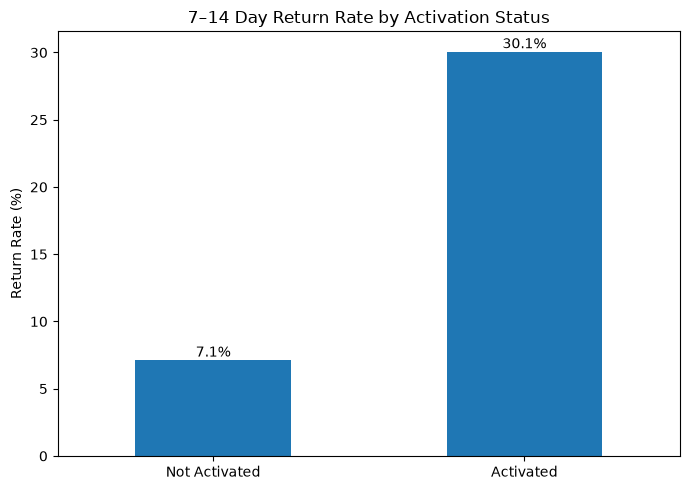

In [25]:
activation_plot = activation_comparison["retention_rate"]

ax = activation_plot.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("7–14 Day Return Rate by Activation Status")
ax.set_xlabel("")
ax.set_ylabel("Return Rate (%)")
ax.set_xticklabels(
    ["Not Activated", "Activated"],
    rotation=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## 11. SQL Product Analysis

SQL is used alongside Python to calculate core product metrics directly from the event-level data.

The analysis focuses on the user journey through the e-commerce funnel and complements the behavioral activation and retention analysis performed in Python.

In [26]:
import duckdb

con = duckdb.connect()
con.register("events", df_clean)

In [27]:
funnel_overview = con.sql("""
SELECT
    event_type,
    COUNT(*) AS total_events,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY event_type
ORDER BY unique_users DESC
""").df()

funnel_overview

,event_type,total_events,unique_users
0,view,1862050,388331
1,cart,1204218,133818
2,remove_from_cart,577579,47090
3,purchase,245281,25762


In [28]:
funnel_conversion = con.sql("""
WITH user_funnel AS (
    SELECT
        user_id,
        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS viewed,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS carted,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchased
    FROM events
    GROUP BY user_id
),

funnel_counts AS (
    SELECT
        SUM(viewed) AS users_viewed,
        SUM(CASE WHEN viewed = 1 AND carted = 1 THEN 1 ELSE 0 END)
            AS users_viewed_and_carted,
        SUM(CASE WHEN viewed = 1 AND carted = 1 AND purchased = 1 THEN 1 ELSE 0 END)
            AS users_completed_funnel
    FROM user_funnel
)

SELECT
    users_viewed,
    users_viewed_and_carted,
    users_completed_funnel,

    ROUND(
        100.0 * users_viewed_and_carted / users_viewed,
        2
    ) AS view_to_cart_rate,

    ROUND(
        100.0 * users_completed_funnel / users_viewed_and_carted,
        2
    ) AS cart_to_purchase_rate,

    ROUND(
        100.0 * users_completed_funnel / users_viewed,
        2
    ) AS overall_view_to_purchase_rate

FROM funnel_counts
""").df()

funnel_conversion

,users_viewed,users_viewed_and_carted,users_completed_funnel,view_to_cart_rate,cart_to_purchase_rate,overall_view_to_purchase_rate
0,388331.0,123260.0,23938.0,31.74,19.42,6.16


In [29]:
sequential_funnel = con.sql("""
WITH first_view AS (
    SELECT
        user_id,
        MIN(event_time) AS first_view_time
    FROM events
    WHERE event_type = 'view'
    GROUP BY user_id
),

first_cart_after_view AS (
    SELECT
        e.user_id,
        MIN(e.event_time) AS first_cart_time
    FROM events e
    INNER JOIN first_view v
        ON e.user_id = v.user_id
    WHERE e.event_type = 'cart'
      AND e.event_time >= v.first_view_time
    GROUP BY e.user_id
),

first_purchase_after_cart AS (
    SELECT
        e.user_id,
        MIN(e.event_time) AS first_purchase_time
    FROM events e
    INNER JOIN first_cart_after_view c
        ON e.user_id = c.user_id
    WHERE e.event_type = 'purchase'
      AND e.event_time >= c.first_cart_time
    GROUP BY e.user_id
)

SELECT
    (SELECT COUNT(*) FROM first_view) AS users_viewed,
    (SELECT COUNT(*) FROM first_cart_after_view) AS users_carted_after_view,
    (SELECT COUNT(*) FROM first_purchase_after_cart) AS users_purchased_after_cart
""").df()

sequential_funnel

,users_viewed,users_carted_after_view,users_purchased_after_cart
0,388331,117874,23138


In [30]:
viewed = sequential_funnel.loc[0, "users_viewed"]
carted = sequential_funnel.loc[0, "users_carted_after_view"]
purchased = sequential_funnel.loc[0, "users_purchased_after_cart"]

print(f"View → Cart conversion: {carted / viewed * 100:.2f}%")
print(f"Cart → Purchase conversion: {purchased / carted * 100:.2f}%")
print(f"View → Purchase conversion: {purchased / viewed * 100:.2f}%")
print()
print(f"View → Cart drop-off: {(1 - carted / viewed) * 100:.2f}%")
print(f"Cart → Purchase drop-off: {(1 - purchased / carted) * 100:.2f}%")

View → Cart conversion: 30.35%
Cart → Purchase conversion: 19.63%
View → Purchase conversion: 5.96%

View → Cart drop-off: 69.65%
Cart → Purchase drop-off: 80.37%


## 12. Key Findings

The analysis identified several patterns in early user behavior and subsequent product engagement:

- Only 8.25% of eligible users reached the proposed activation milestone of at least 2 sessions and 4 unique products viewed within their first 3 observed days.
- Activated users showed a 30.07% observed 7–14 day return rate, compared with 7.14% among non-activated users — a 4.21× difference.
- Return rates increased consistently with deeper early product exploration. Users viewing 0–1 unique products had a 4.97% return rate, compared with 20.60% for users viewing 4–5 products and 34.92% for users viewing 11+ products.
- The sequential funnel showed a 30.35% View → Cart conversion rate and a 19.63% Cart → Purchase conversion rate.
- The largest observed stage-to-stage funnel drop-off occurred between Cart and Purchase (80.37%).

These findings suggest two potential product opportunities: improving early product discovery and investigating friction between cart and purchase.

Because the strongest behavioral signal is associated with early engagement and activation, this case study focuses the proposed intervention on improving early product discovery.

## 13. Product Recommendation

### Personalized Product Discovery

The analysis indicates that deeper and repeated early product engagement is strongly associated with subsequent user return. At the same time, relatively few users currently reach the proposed activation milestone.

Based on these findings, the proposed product intervention is a **personalized product discovery module** designed to help users explore relevant products more easily during their early experience.

The module could surface recommendations based on products or categories a user has already explored and appear on product pages or other high-visibility discovery areas through sections such as **"You might also like"** or **"Recommended for you."**

The intervention is intended to:
- increase relevant product exploration,
- increase the number of unique products viewed,
- encourage repeated early engagement,
- increase the share of users reaching the activation milestone.

The proposed behavioral pathway is:

**Personalized discovery → deeper product exploration → higher activation → potential improvement in subsequent retention**

The funnel analysis also identifies substantial drop-off between cart and purchase. However, because the dataset does not provide information about checkout behavior, payment issues, shipping costs, or other potential sources of friction, further diagnostic data would be required before recommending a specific checkout intervention.

## 14. A/B Testing Framework

The observational analysis shows a strong association between early product engagement and subsequent return behavior, but it cannot establish causality.

A controlled A/B test is therefore proposed to evaluate whether the personalized product discovery module can increase user activation.

### Hypothesis

Users exposed to personalized product recommendations during their early experience will be more likely to reach the proposed activation milestone than users receiving the existing product experience.

### Experiment Groups

**Control (A):** Existing product experience without the personalized product discovery module.

**Treatment (B):** Existing product experience with personalized product recommendations displayed in relevant discovery areas.

Users would be randomly assigned to one of the two groups at the user level and remain in the same group throughout the experiment.

### Experiment Metrics

#### Primary Metric — Activation Rate

The primary metric is the percentage of users who reach the proposed activation milestone:

**At least 2 sessions and at least 4 unique products viewed within the first 3 observed days.**

Activation Rate = Activated Users / Eligible Users

Activation is selected as the primary metric because the proposed recommendation module is designed to directly influence early product exploration and repeated engagement.

#### Secondary Metrics

Secondary metrics provide additional evidence about how the intervention changes user behavior:

- **Unique products viewed per user** — measures the depth of product exploration.
- **Second-session rate** — measures whether users return for another session during the early observation period.
- **7–14 day return rate** — evaluates whether increased activation is accompanied by improved subsequent return behavior.
- **Purchase conversion rate** — evaluates whether the intervention is associated with downstream commercial behavior.

#### Guardrail Metrics

Guardrail metrics are monitored to ensure that improvements in activation do not negatively affect other important parts of the user experience:

- **Remove-from-cart rate** — monitors whether increased discovery is accompanied by excessive cart removal behavior.
- **Cart-to-purchase conversion rate** — ensures that increased product exploration does not reduce progression toward purchase.

### Sample Size Planning

The current activation rate of 8.25% is used as the baseline for experiment planning.

The experiment is designed to detect a 15% relative improvement in activation rate, corresponding to an increase from approximately 8.25% to 9.49%.

The sample size calculation assumes:

- Significance level (α): 0.05
- Statistical power: 80%
- Two-sided test
- Equal allocation between control and treatment groups

In [31]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_activation = 0.0825
relative_mde = 0.15

target_activation = baseline_activation * (1 + relative_mde)

effect_size = proportion_effectsize(
    baseline_activation,
    target_activation
)

sample_size_per_group = NormalIndPower().solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

print(f"Baseline activation rate: {baseline_activation:.2%}")
print(f"Target activation rate: {target_activation:.2%}")
print(f"Required users per group: {sample_size_per_group:.0f}")
print(f"Total required users: {sample_size_per_group * 2:.0f}")

Baseline activation rate: 8.25%
Target activation rate: 9.49%
Required users per group: 8275
Total required users: 16550


In [32]:
daily_first_observed_users = (
    first_activity
    .dt.normalize()
    .value_counts()
    .sort_index()
)

print(
    "Average first-observed users per day:",
    round(daily_first_observed_users.mean())
)
print(
    "Median first-observed users per day:",
    round(daily_first_observed_users.median())
)

daily_first_observed_users.head(10)

Average first-observed users per day: 12892
Median first-observed users per day: 11199


first_activity
2019-10-01 00:00:00+00:00    19230
2019-10-02 00:00:00+00:00    31739
2019-10-03 00:00:00+00:00    13356
2019-10-04 00:00:00+00:00    11438
2019-10-05 00:00:00+00:00    11997
2019-10-06 00:00:00+00:00    27849
2019-10-07 00:00:00+00:00    21818
2019-10-08 00:00:00+00:00    15268
2019-10-09 00:00:00+00:00    12914
2019-10-10 00:00:00+00:00    11805
Name: count, dtype: int64

### Experiment Duration

The dataset contains approximately 12,892 first-observed users per day on average (median: 11,199).

Given the required sample size of approximately 16,550 users, the experiment could theoretically reach the required sample within a few days under a 50/50 traffic split.

However, the experiment should not be stopped immediately after reaching the minimum sample size.

A **minimum 14-day enrollment period** is proposed in order to:

- capture variation across multiple weekly cycles,
- reduce sensitivity to individual high- or low-traffic days,
- allow users sufficient time to complete the 3-day activation window,
- collect a more representative experiment sample.

After enrollment ends, an additional **14-day follow-up period** is required for the final enrolled users before evaluating the 7–14 day return metric.

Therefore:

**Primary activation analysis:** available shortly after the 14-day enrollment period and completion of the activation window.

**Final downstream retention analysis:** conducted after the additional 14-day follow-up period.

### Decision Rule and Statistical Analysis

The primary analysis compares the activation rate between the control and treatment groups.

A two-proportion statistical test would be used to evaluate whether the difference in activation rates between the two groups is statistically significant.

The experiment would support launching the personalized discovery module if:

- the treatment group shows a statistically significant improvement in activation rate at **α = 0.05**,
- the observed improvement is large enough to be practically meaningful,
- key guardrail metrics do not show meaningful deterioration.

A statistically significant result alone would not automatically justify launch. The magnitude of the effect, confidence interval, downstream metrics, and potential negative effects would also be considered.

If activation improves but downstream return or purchase behavior deteriorates, the feature should be investigated or iterated before a full rollout.

If no meaningful improvement in activation is detected, the hypothesis would not be supported and the recommendation experience should be reconsidered or redesigned.

## 15. Limitations

This analysis has several important limitations:

- The dataset covers only one month of user activity, limiting the ability to evaluate longer-term retention and seasonality.
- A user's first observed event in the dataset does not necessarily represent their true first interaction with the product.
- The dataset contains behavioral event data but does not include user demographics, acquisition channels, device information, marketing exposure, or other contextual variables that could influence engagement and retention.
- The observed relationship between activation and subsequent return is correlational and should not be interpreted as causal.
- The proposed activation milestone was selected using the same dataset on which its relationship with retention was evaluated. It should therefore be validated on an independent time period or through experimentation.
- The large cart-to-purchase drop-off cannot be fully diagnosed because the dataset does not include checkout steps, payment failures, shipping costs, or other potential sources of purchase friction.
- The proposed personalized recommendation feature was not implemented or experimentally tested; the A/B test represents a framework for future validation.

## 16. Conclusion

This case study analyzed more than 4 million product interaction events to investigate early user behavior, activation, retention, and conversion.

The analysis identified a proposed activation milestone of at least 2 sessions and 4 unique products viewed within the first 3 observed days. Approximately 8.25% of eligible users reached this milestone, and activated users showed a 30.07% subsequent 7–14 day return rate compared with 7.14% among non-activated users.

SQL funnel analysis further showed that 30.35% of users who viewed a product subsequently reached cart, while 19.63% of users who reached cart after viewing subsequently reached purchase.

Based on the behavioral findings, a personalized product discovery module was proposed to encourage deeper early exploration and increase activation. An A/B testing framework was designed to evaluate the intervention using activation rate as the primary metric, supported by downstream and guardrail metrics.

Overall, the case demonstrates how behavioral data can be translated from exploratory analysis into a measurable product opportunity and an experiment-driven product decision.